  ## SHAP Explainability

This notebook uses SHAP (SHapley Additive exPlanations) to interpret the Random Forest model used for Remaining Useful Life (RUL) prediction.

The objective is to understand:

- Which features are most important for RUL prediction.
- How individual features influence the predicted RUL.
- Why the model makes a particular RUL prediction.
- The difference between global and local model explanations.

In [1]:
%pip install shap 

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

In [3]:
import joblib

# Load the trained Random Forest RUL model
rf_reg = joblib.load("rf_rul_model.pkl")

# Load the validation features
X_val_imputed = pd.read_csv("X_val_imputed.csv")

print("Random Forest model loaded successfully.")
print("Validation data shape:", X_val_imputed.shape)

Random Forest model loaded successfully.
Validation data shape: (4070, 64)


In [4]:
# Create SHAP Tree Explainer for the Random Forest model
explainer = shap.TreeExplainer(rf_reg)

print("SHAP TreeExplainer created successfully.")

SHAP TreeExplainer created successfully.


In [5]:
# Select a representative sample of validation data
X_shap = X_val_imputed.sample(
    n=200,
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (200, 64)


In [6]:
# Calculate SHAP values for the sample
shap_values = explainer(X_shap)

print("SHAP values calculated successfully.")
print("SHAP values shape:", shap_values.values.shape)

SHAP values calculated successfully.
SHAP values shape: (200, 64)


In [7]:
# Calculate mean absolute SHAP importance for each feature

shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Abs_SHAP": np.abs(shap_values.values).mean(axis=0)
})

# Sort features from most important to least important
shap_importance = shap_importance.sort_values(
    "Mean_Abs_SHAP",
    ascending=False
)

shap_importance.head(15)

,Feature,Mean_Abs_SHAP
0,cycle,42.247577
25,sensor_4_rolling_mean,6.819851
52,sensor_15_rolling_mean,6.273004
40,sensor_11_rolling_mean,5.729433
37,sensor_9_rolling_mean,4.081851
49,sensor_14_rolling_mean,3.145951
43,sensor_12_rolling_mean,1.871632
61,sensor_21_rolling_mean,1.484170
34,sensor_8_rolling_mean,1.408494
19,sensor_2_rolling_mean,1.393667


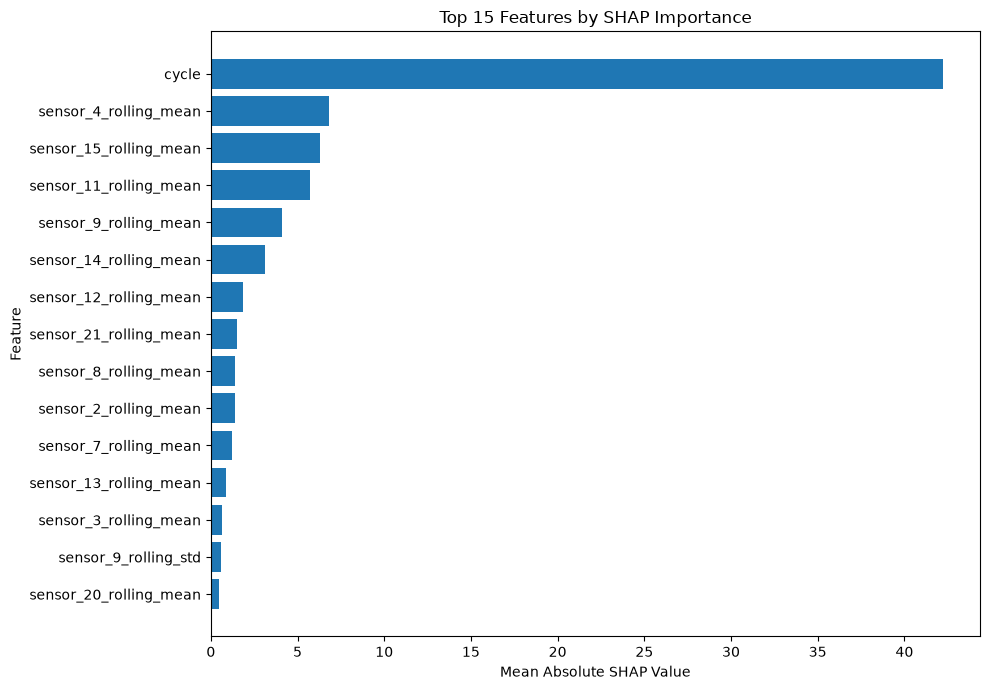

In [9]:
# Plot the top 15 most important features

top_features = shap_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Mean_Abs_SHAP"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 15 Features by SHAP Importance")

plt.tight_layout()
plt.show()

In [10]:
# Select one observation from the SHAP sample

sample_index = 0

print("Actual feature values:")
print(X_shap.iloc[sample_index])

print("\nModel predicted RUL:")
print(rf_reg.predict(X_shap.iloc[[sample_index]])[0])

Actual feature values:
cycle                     145.000000
setting_1                  -0.002400
setting_2                   0.000300
setting_3                 100.000000
sensor_2                  642.480000
                             ...    
sensor_20_rolling_std       0.150566
sensor_20_delta            -0.010000
sensor_21_rolling_mean     23.347560
sensor_21_rolling_std       0.043900
sensor_21_delta             0.008300
Name: 605, Length: 64, dtype: float64

Model predicted RUL:
122.77


C:\Users\avnis\anaconda3_newml\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


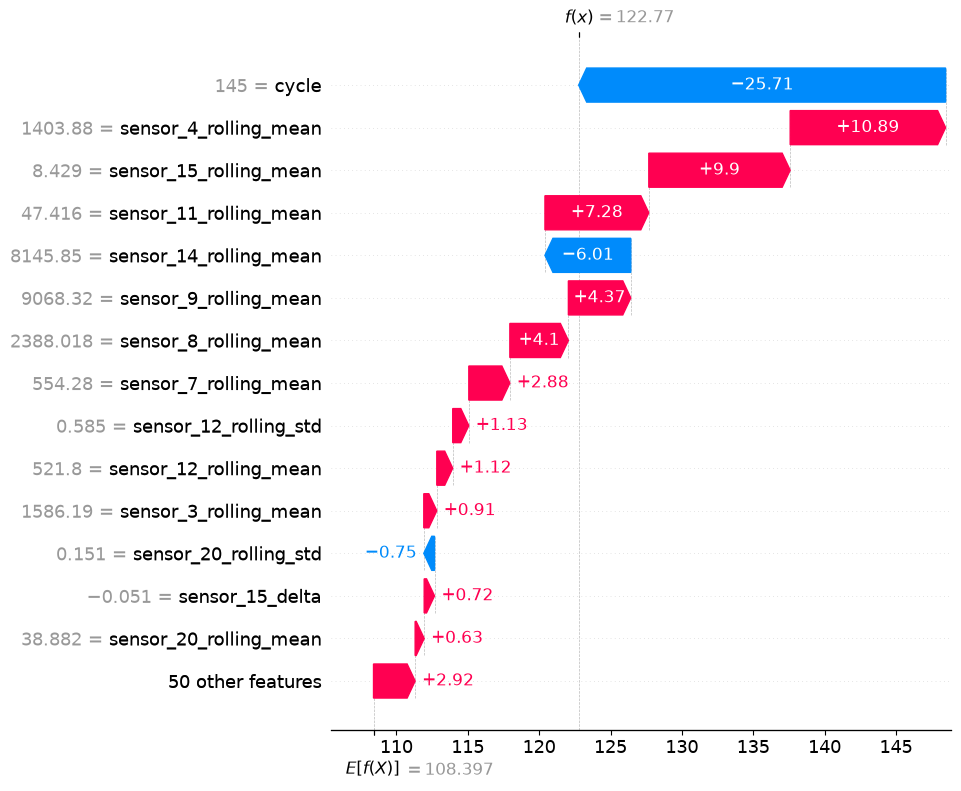

In [11]:
# Create a SHAP waterfall plot for this individual prediction

shap.plots.waterfall(
    shap_values[sample_index],
    max_display=15
)